In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv("C:/Users/kevinjfei/python_decal_fa25/course_assignments/homework9/solar_system.csv")

In [11]:
df = df.set_index("Attribute")
df.shape

(20, 10)

In [10]:
df.head

<bound method NDFrame.head of                       Attribute Mercury    Venus  Earth   Moon   Mars  \
0                Mass (10^24kg)   0.330     4.87   5.97  0.073  0.642   
1                 Diameter (km)    4879    12104  12756   3475   6792   
2              Density (kg/m^3)    5429     5243   5514   3340   3934   
3               Gravity (m/s^2)     3.7      8.9    9.8    1.6    3.7   
4        Escape Velocity (km/s)     4.3     10.4   11.2    2.4    5.0   
5       Rotation Period (hours)  1407.6  -5832.5   23.9  655.7   24.6   
6         Length of Day (hours)  4222.6   2802.0   24.0  708.7   24.7   
7   Distance from Sun (10^6 km)    57.9    108.2  149.6  0.384  228.0   
8          Perihelion (10^6 km)    46.0    107.5  147.1  0.363  206.7   
9            Aphelion (10^6 km)    69.8    108.9  152.1  0.406  249.3   
10        Orbital Period (days)    88.0    224.7  365.2   27.3  687.0   
11      Orbital Velocity (km/s)    47.4     35.0   29.8    1.0   24.1   
12    Orbital Inclina

In [ ]:
df.tail

In [7]:
print(df.columns.tolist)


<bound method IndexOpsMixin.tolist of Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')>


In [12]:
print(df.index) # or df["Attributes"]

Index(['Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)',
       'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)',
       'Length of Day (hours)', 'Distance from Sun (10^6 km)',
       'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)',
       'Orbital Velocity (km/s)', 'Orbital Inclination (deg)',
       'Orbital Eccentricity', 'Obliquity to Orbit (deg)',
       'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons',
       'Ring System?', 'Global Magnetic Field?'],
      dtype='object', name='Attribute')


In [8]:
print(df.columns)

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [14]:
perihelion = df.loc["Perihelion (10^6 km)"].astype(float) 
aphelion = df.loc["Aphelion (10^6 km)"].astype(float) 
period = df.loc["Orbital Period (days)"].astype(float) 

# period = 1 orbit around star
# perihelion = d closest to star
# aphelion = d farthest from star 

In [15]:
semi_major_axis = (perihelion + aphelion) / 2

In [17]:
df.loc["Semi-major axis (AU)"] = semi_major_axis
df.shape

(21, 10)

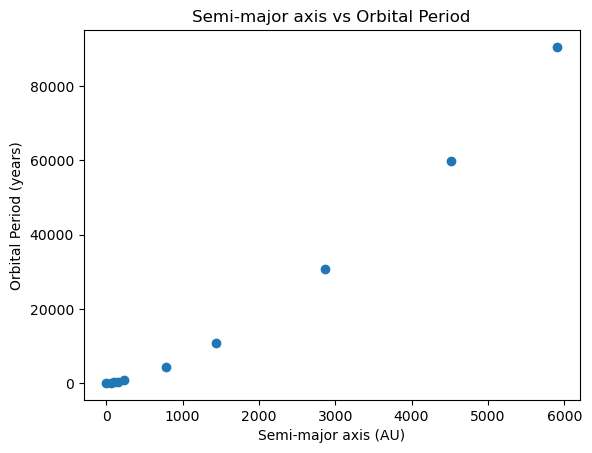

In [19]:
plt.scatter(semi_major_axis, period)
plt.xlabel("Semi-major axis (AU)")
plt.ylabel("Orbital Period (years)")
plt.title("Semi-major axis vs Orbital Period")
# plt.legend() idk what to legend here
plt.show()

In [34]:
def keplers_third_law(a, m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, period)
m = popt[0]

print(f"Fit: T = {m:.2f} * a^(3/2)")

residuals = period - keplers_third_law(semi_major_axis, m)
chi2 = np.sum(residuals**2)
dof = len(period) - len(popt)
chi2_reduced = chi2 / dof

Fit: T = 0.20 * a^(3/2)


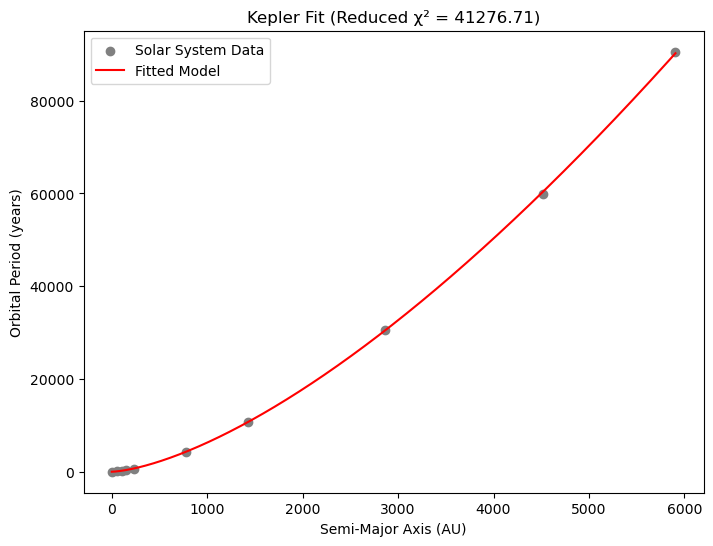

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(semi_major_axis, period, color = "gray", label = "Solar System Data")

x = np.linspace(min(semi_major_axis), max(semi_major_axis), 500)
plt.plot(x, keplers_third_law(x, m), color = "red", linestyle = "-", label = "Fitted Model")

plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (years)")

plt.title(f"Kepler Fit (Reduced χ² = {chi2_reduced:.2f})")

plt.legend()
plt.show()

In [36]:
df.to_csv("kepler.csv", index=False)